In [1]:
%matplotlib inline

In [2]:
import xtrack as xt
import xpart as xp
import matplotlib.pyplot as plt

import numpy as np

### Compute multi-species ratios

In [3]:
# Create particles
p0_car = xt.Particles('Carbon-12')
p0_hel = xt.Particles('Helium-4')

Charge and mass correspond to the fully ionized state:

In [4]:
p0_car.q0, p0_hel.q0 # charge in units of elementary charge

(np.float64(6.0), np.float64(2.0))

In [5]:
p0_car.mass0, p0_hel.mass0 # eV

(np.float64(11174864281.0), np.float64(3727379411.8))

We will configure the ring to circulate Carbon and study the dynamics of Helium and Carbon together.

Compute useful auxiliary quantities:

In [6]:
mass_ratio_hel_car = p0_hel.mass0 / p0_car.mass0
charge_ratio_hel_car = p0_hel.q0 / p0_car.q0


Ratio of charge-mass ratios:


$\displaystyle 
\quad \quad \chi_{\mathrm{He}} =
\frac{q_{\mathrm{He}}}{q_{\mathrm{C}}}
\frac{m_{\mathrm{C}}}{m_{\mathrm{He}}}$



In [7]:
chi_hel = charge_ratio_hel_car / mass_ratio_hel_car

In [8]:
chi_hel

np.float64(0.9993495023718296)

### Load the line

In [9]:
env = xt.load('./pimm.json')
env.vars.load('./pimm_strengths.json')
line = env.ring
line.configure_bend_model(core='bend-kick-bend')#num_multipole_kicks=5)

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

### Configure RF

In [10]:
line['rf1'].harmonic = 1
line['vrf'] = 0.5e3            # V

### Set Carbon at 200 MeV / nucleon as reference particle

In [11]:
line.set_particle_ref('Carbon-12', kinetic_energy0=200e6 * 12)

### Compute nominal twiss

In [12]:
tw_car = line.twiss()

### Longitudinal coordinate definition

The coordinate $\delta$ in Xsuite is defined as:

$\displaystyle 
\quad \quad \delta = \frac{P \frac{m_0}{m} - P_0}{P_0}
= \frac{\beta \gamma}{\beta_0 \gamma_0} - 1
$

With this definition the motion is described by the following Hamiltonian:

$\displaystyle 
H_\delta=\frac{1+\delta}{\beta \beta_0}-(1+h x)\left(\sqrt{\left(\frac{1+\delta}{\beta}-\chi \varphi\right)^2-\frac{1}{\beta_0^2 \gamma_0^2}-\left(p_x-\chi a_x\right)^2-\left(p_y-\chi a_y\right)^2}+\chi a_s\right)
$

For analytic estimates it is useful to introduce also a rigidity deviation, which depends on both $\delta$ and $\chi$:

$\displaystyle 
\quad \quad \delta_\text{rig} = \frac{P/q}{P_0/q_0} - 1 = \frac{1 + \delta}{\chi} - 1
$

### Compute twiss for helium beam

In [13]:
tw_hel = line.twiss6d(mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

We can see that, having different rigidity, the helium needs to move off energy to remain synchronous with the RF.


In [14]:
tw_car.delta[0]

np.float64(0.0)

In [15]:
tw_hel.delta[0]

np.float64(0.0004391552493416828)

### Compute expected momentum deviation
The momentum deviation between the two beams can also be expressed analytically:

$\displaystyle 
\quad \quad \delta_\text{diff} =
\frac{\alpha}{\eta} (\chi_\text{He} -1)
$

In [16]:
eta = tw_car.slip_factor
alpha = tw_car.momentum_compaction_factor

delta_diff_expected = alpha / eta * (chi_hel - 1)

In [17]:
delta_diff_expected # Consistent with Twiss result

np.float64(0.00043761229102840665)

### Plot orbit for the two beams

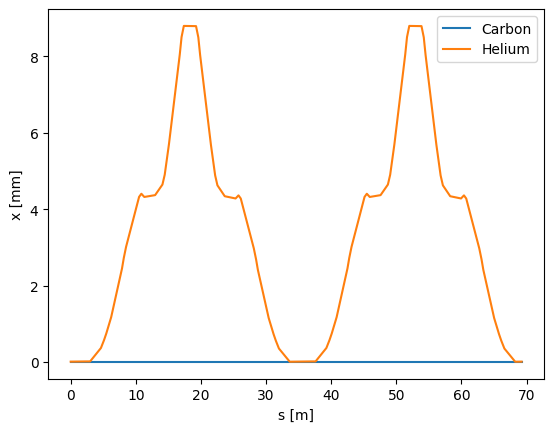

In [18]:
plt.figure()
plt.plot(tw_car.s, 1e3 * tw_car.x, label='Carbon')
plt.plot(tw_hel.s, 1e3 * tw_hel.x, label='Helium')
plt.xlabel('s [m]')
plt.ylabel('x [mm]')
plt.legend()

### Center the beams using rf frequency shift

The beam position in a dispersive region can be written as:

$\displaystyle 
x(s) = D_x(s) \delta_\text{rig} \simeq D_x(s) \left(\delta + (1 - \chi)\right)
$

A change in revolution period from an RF frequency trim can be modelled by introducing a compensating time delay in the line. To first order, a momentum shift $\Delta\delta$ changes the physical revolution period by:

$\displaystyle
\Delta T_\mathrm{rev} = \eta T_\mathrm{rev0}\Delta\delta.
$

The corresponding longitudinal drift over one turn is:

$\displaystyle
\Delta\zeta_\mathrm{ring} = -\beta_0 c\,\Delta T_\mathrm{rev}
= -\eta L_\mathrm{circ}\Delta\delta.
$


In [19]:
env['dp'] = 0
line.append(
    env.new('tdelay', xt.TimeDelay, shift_zeta=-eta * line.get_length() * env.ref['dp']))

In [20]:
env['dp'] = -5.5e-4
tw_car = line.twiss6d()
tw_hel = line.twiss6d(mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

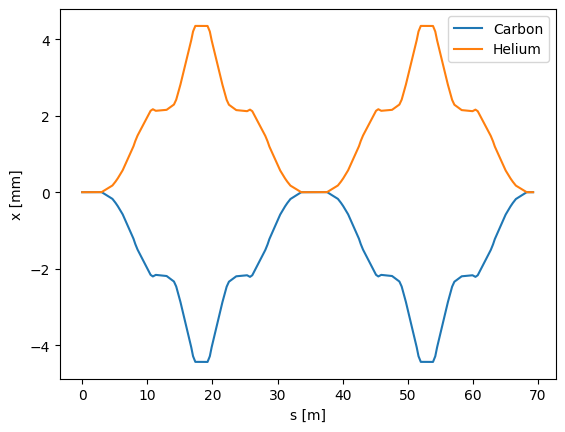

In [21]:
plt.figure()
plt.plot(tw_car.s, 1e3 * tw_car.x, label='Carbon')
plt.plot(tw_hel.s, 1e3 * tw_hel.x, label='Helium')

# # Check against analytic formula
# plt.plot(tw_car.s, 1e3 * 
#          tw_car.dx * tw_car.delta, '--', color='C3', label='Car. formula')
# plt.plot(tw_car.s, 
#          1e3 * tw_car.dx * (tw_hel.delta - (chi_hel - 1)), '--', color='C2', label='Car. formula')

plt.xlabel('s [m]')
plt.ylabel('x [mm]')
plt.legend()

The two beams still have different delta:

In [22]:
tw_car.delta[0], tw_hel.delta[0]

(np.float64(-0.0005493171118901019), np.float64(-0.00011187671687218348))

The difference between the two stays unchanged:

In [23]:
tw_hel.delta[0] - tw_car.delta[0]

np.float64(0.0004374403950179184)

### Effect of tune and chromaticity on the two beams

In [24]:
# Set the chromaticity to zero
env['chrom_x'] = 0
env['chrom_y'] = 0
tw_car = line.twiss6d()
tw_hel = line.twiss6d(mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

For **zero chromaticity**, the two species have essentially the same tunes:

In [25]:
tw_hel.qx - tw_car.qx, tw_hel.qy - tw_car.qy

(np.float64(-8.03614534916619e-08), np.float64(4.581801604786051e-11))

In [26]:
# Set non-zero chromaticity
env['chrom_x'] = 1.
env['chrom_y'] = 1.
tw_car = line.twiss6d()
tw_hel = line.twiss6d(mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

For **non-zero chromaticity**, there is a measurable tune shift between the two species:

In [27]:
tw_hel.qx - tw_car.qx, tw_hel.qy - tw_car.qy

(np.float64(0.0010879639567002997), np.float64(0.0010883017325689082))

Also the effect of chromaticity can be **expressed analytically**:

$\displaystyle 
Q_x = Q_{x0} + Q'_{x} \delta_\text{rig} \simeq Q_{x0} + Q'_{x} \left(\delta + (1 - \chi)\right)
$

In [28]:
qx_shift_expected = tw_car.dqx * (tw_hel.delta[0] + (1 - chi_hel) - tw_car.delta[0])
qx_shift_expected

np.float64(0.0010493822168154577)

### Inspect the longitudinal plane

In [29]:
# Create C and He particles with different momentum deviation from the respective closed orbit 
delta_test = np.linspace(-1e-3, 1e-3, 20)
p_car = line.build_particles(delta=tw_car.delta[0] + delta_test)
p_hel = line.build_particles(delta=tw_hel.delta[0] + delta_test, mass_ratio=mass_ratio_hel_car, charge_ratio=charge_ratio_hel_car)

In [30]:
num_turns=5000
# Track the carbon particles saving turn-by-turn data
line.track(p_car, num_turns=num_turns, turn_by_turn_monitor=True, with_progress=10)
mon_carbon = line.record_last_track.copy()
# Track the He particle saving turn-by-turn data
line.track(p_hel, num_turns=num_turns, turn_by_turn_monitor=True, with_progress=10)
mon_helium = line.record_last_track.copy()

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

Tracking:   0%|          | 0/5000 [00:00<?, ?it/s]

Text(0, 0.5, '$\\delta$')

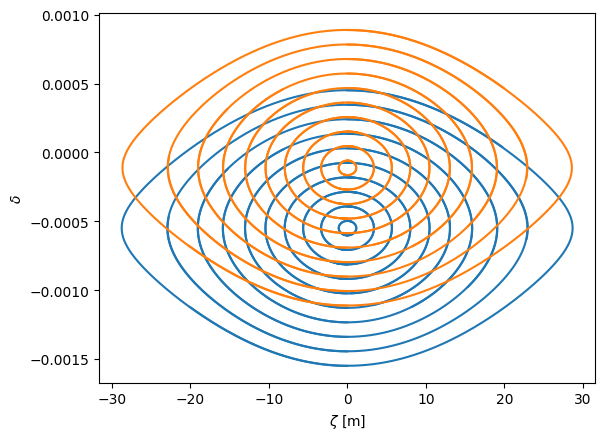

In [31]:
plt.plot(mon_carbon.zeta.T, mon_carbon.delta.T, color='C0')
plt.plot(mon_helium.zeta.T, mon_helium.delta.T, color='C1')
plt.xlabel(r'$\zeta$ [m]')
plt.ylabel(r'$\delta$')